<a href="https://colab.research.google.com/github/alunkingusw/meeting_diarisation/blob/master/tutorials/pyannote_3_4_0_finetuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Powerset multi-class cross entropy loss for neural speaker diarization - Adapted for Colab 2025.10 build by Alun

This is the example notebook of the paper "*Powerset multi-class cross entropy loss for neural speaker diarization*", published at Interspeech 2023.

The corresponding official repository is available here

## Installing dependencies

Make sure you're **using a GPU** (Runtime -> Change runtime type) before starting the notebook.

Please download the ckpt file at https://github.com/FrenchKrab/IS2023-powerset-diarization/blob/master/models/powerset/powerset_pretrained.ckpt and place it in `/content/`.

**Restart the runtime once this part is complete** (Runtime -> Restart runtime) and then continue to next part, else you will encounter a pyannote.database error.

In [2]:
# Note: pyannote.audio's version is the oldest compatible version tested with this method.
# pyannote.database version 5.1 (newer) is used for convenience and ease of use.
!pip install -qq rich
!pip install -qq pyannote.audio==3.4.0
!pip install -qq pyannote.database==5.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.9/44.9 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 11.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.8/897.8 kB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 846.0/846.0 kB 84.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.5/58.5 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.1/48.1 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.4/51.4 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.8/127.8 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 864.1/864.1 kB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.5/48.5 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [1]:
#Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Get Hugging Face secret token
from google.colab import userdata
HUGGING_FACE = userdata.get('HUGGING_FACE')

Mounted at /content/drive


In [3]:
# move the files previously downloaded (faster than redownloading)
%cp -r /content/drive/MyDrive/ColabFiles/new_training/AMI-diarization-setup-SDM /content/
%cp -r /content/drive/MyDrive/ColabFiles/new_training/AMI-diarization-setup-IHM-synth /content/

In [ ]:
# download AMI-SDM mini corpus for testing if not already downloaded on drive
%cd /content/
!git clone https://github.com/pyannote/AMI-diarization-setup
%cp -r /content/AMI-diarization-setup/ /content/AMI-diarization-setup-SDM
%mv /content/AMI-diarization-setup/ /content/AMI-diarization-setup-IHM
%cd /content/AMI-diarization-setup-SDM/pyannote/
!bash download_ami_sdm.sh

#download AMI-IHM mini corpus for training
%cd /content/AMI-diarization-setup-IHM/pyannote/
!bash download_ami.sh

#download the AMI-

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content
Cloning into 'AMI-diarization-setup'...
remote: Enumerating objects: 977, done.
remote: Counting objects: 100% (977/977), done.
remote: Compressing objects: 100% (429/429), done.
remote: Total 977 (delta 390), reused 949 (delta 369), pack-reused 0 (from 0)
Receiving objects: 100% (977/977), 1.67 MiB | 5.50 MiB/s, done.
Resolving deltas: 100% (390/390), done.
/content/AMI-diarization-setup-SDM/pyannote
ES2002d.Array1-01.w 100%[===================>]  80.08M  14.2MB/s    in 6.5s    
2026-01-14 20:57:28 URL:https://groups.inf.ed.ac.uk/ami/AMICorpusMirror/amicorpus/ES2002d/audio/ES2002d.Array1-01.wav [83974526/83974526] -> "amicorpus/ES2002d/audio/ES2002d.Array1-01.wav" [1]
ES2003a.Array1-01.w 100%[===================>]  34.78M  11.0MB/s    in 3.2s    
2026-01-14 20:57:32 URL:https://groups.inf.ed.ac.uk/ami/AMICorpusMirror/amicorpus/ES2003a/audio/ES2003a.

#Generate RIR Bank
This is used to create RIRs for synthetic creation of SDR audio from IHR recordings

In [ ]:
!pip install pyroomacoustics
import numpy as np
import soundfile as sf
import pyroomacoustics as pra
from pathlib import Path
import random

TARGET_SR = 16000
OUT_DIR = Path("/content/drive/MyDrive/ColabFiles/rir_bank")
N_RIRS = 20

OUT_DIR.mkdir(exist_ok=True)

def generate_random_rir(idx):
    # -----------------------------
    # Random room
    # -----------------------------
    room_dim = [
        random.uniform(8.0, 12.0),
        random.uniform(5.0, 8.0),
        random.uniform(2.7, 3.2),
    ]

    rt60 = random.uniform(0.35, 0.65)
    absorption, max_order = pra.inverse_sabine(rt60, room_dim)

    room = pra.ShoeBox(
        room_dim,
        fs=TARGET_SR,
        materials=pra.Material(absorption),
        max_order=max_order
    )

    # -----------------------------
    # Microphone (SDM)
    # -----------------------------
    mic_position = np.array([
        room_dim[0] / 2 + random.uniform(-0.3, 0.3),
        room_dim[1] / 2 + random.uniform(-0.3, 0.3),
        random.uniform(1.1, 1.4)
    ]).reshape(3, 1)

    room.add_microphone_array(
        pra.MicrophoneArray(mic_position, room.fs)
    )

    # -----------------------------
    # Speaker
    # -----------------------------
    distance = random.uniform(2.0, 5.0)
    angle = random.uniform(-np.pi / 4, np.pi / 4)

    source_position = [
        mic_position[0, 0] + distance * np.cos(angle),
        mic_position[1, 0] + distance * np.sin(angle),
        random.uniform(1.4, 1.7)
    ]

    # Keep source inside room
    source_position[0] = np.clip(source_position[0], 0.5, room_dim[0] - 0.5)
    source_position[1] = np.clip(source_position[1], 0.5, room_dim[1] - 0.5)

    room.add_source(source_position)

    # -----------------------------
    # Compute RIR
    # -----------------------------
    room.compute_rir()
    rir = room.rir[0][0]

    # Normalize & trim
    rir = rir / (np.max(np.abs(rir)) + 1e-9)
    rir = rir[:int(TARGET_SR * 1.5)]  # 1.5s max

    # Save
    out_path = OUT_DIR / f"rir_{idx:03d}.wav"
    sf.write(out_path, rir, TARGET_SR)

    print(f"Generated {out_path}")

if __name__ == "__main__":
    for i in range(N_RIRS):
        generate_random_rir(i)


#Convert IHM Training data to SDM Synthetic Training Data

In [4]:
import os
import random
import numpy as np
import soundfile as sf
from scipy.signal import fftconvolve, butter, lfilter

from pyannote.audio import Audio
from pyannote.core import Segment

from pyannote.database import registry, FileFinder

registry.load_database("/content/AMI-diarization-setup-IHM/pyannote/database.yml")
protocol = registry.get_protocol("AMI.SpeakerDiarization.only_words", preprocessors={"audio": FileFinder()})

# ---------------------------------
# Configuration
# ---------------------------------

TARGET_SR = 16000
FRAME_HOP = 0.01  # 10 ms

# get the rir files
rir_dir = "/content/drive/MyDrive/ColabFiles/rir_bank"
rir_files = [os.path.join(rir_dir, f) for f in os.listdir(rir_dir) if f.endswith(".wav")]

audio_loader = Audio(sample_rate=TARGET_SR, mono=True)

random.seed(12)

# ---------------------------------
# Utilities
# ---------------------------------

def butter_filter(signal, cutoff, btype, sr, order=4):
    nyq = 0.5 * sr
    norm = cutoff / nyq
    b, a = butter(order, norm, btype=btype)
    return lfilter(b, a, signal)

def annotation_to_activity(annotation, duration):
    n_frames = int(np.ceil(duration / FRAME_HOP))
    activity = np.zeros(n_frames)

    for segment in annotation.itersegments():
        start = segment.start
        end = segment.end
        s = int(start / FRAME_HOP)
        e = int(end / FRAME_HOP)
        activity[s:e] += 1

    return activity

def expand_frames(frames, n_samples):
    samples_per_frame = int(TARGET_SR * FRAME_HOP)
    expanded = np.repeat(frames, samples_per_frame)
    return expanded[:n_samples]

def load_rir_as_mono(rir_path):
    """Load RIR and ensure it's mono (1D)"""
    rir, _ = sf.read(rir_path)
    rir = rir.astype(np.float32)

    # Convert to mono if stereo/multichannel
    if rir.ndim > 1:
        rir = rir.mean(axis=1)

    # Ensure it's 1D
    rir = np.squeeze(rir)

    # Normalize
    rir = rir / (np.max(np.abs(rir)) + 1e-9)

    return rir

def load_audio_as_mono(file_path):
    """Load audio and FORCE it to be mono (1D)"""
    waveform, sr = audio_loader(file_path)
    audio = waveform.numpy()

    # Force mono conversion if multi-channel
    if audio.ndim > 1:
        # Average across channel dimension (first dimension after batch)
        audio = audio.mean(axis=0)

    # Remove any remaining singleton dimensions
    audio = np.squeeze(audio)

    # Final safety check
    if audio.ndim != 1:
        raise ValueError(f"Could not convert to mono 1D array. Shape: {audio.shape}")

    return audio

# ---------------------------------
# Count total files first
# ---------------------------------

print("Counting files...")
train_files = list(protocol.train())
dev_files = list(protocol.development())

total_train = len(train_files)
total_dev = len(dev_files)
total_files = total_train + total_dev

print(f"\nTotal files to process:")
print(f"  Training: {total_train}")
print(f"  Development: {total_dev}")
print(f"  TOTAL: {total_files}")
print("="*70)

# ---------------------------------
# Main processing - TRAINING
# ---------------------------------

print(f"\nProcessing TRAINING files ({total_train} files)...")
print("="*70)

for idx, file in enumerate(train_files, 1):

    meeting_id = file.get("uri", "unknown")
    print(f"[{idx}/{total_train}] Processing: {meeting_id}")

    # Output path - overwrite the original IHM file
    out_wav = file['audio']

    try:
        # -----------------------------
        # Load IHM mix audio - FORCE MONO
        # -----------------------------
        audio = load_audio_as_mono(file["audio"])

        audio = audio / (np.max(np.abs(audio)) + 1e-9)
        n_samples = len(audio)
        duration = n_samples / TARGET_SR

        # -----------------------------
        # Distance filtering
        # -----------------------------
        audio = butter_filter(audio, 80, "high", TARGET_SR)
        audio = butter_filter(audio, 7500, "low", TARGET_SR)

        # -----------------------------
        # Diarisation activity
        # -----------------------------
        annotation = file["annotation"]
        activity = annotation_to_activity(annotation, duration)

        single = (activity == 1).astype(float)
        overlap = (activity >= 2).astype(float)
        silence = (activity == 0).astype(float)

        single = expand_frames(single, n_samples)
        overlap = expand_frames(overlap, n_samples)
        silence = expand_frames(silence, n_samples)

        # -----------------------------
        # Load random RIR (fixed per meeting)
        # -----------------------------
        rir_path = random.choice(rir_files)
        rir = load_rir_as_mono(rir_path)

        # -----------------------------
        # Convolution reverb
        # -----------------------------
        wet = fftconvolve(audio, rir)[:n_samples]
        dry = audio

        # -----------------------------
        # Diarisation-aware mixing
        # -----------------------------
        base_dry = 0.35
        dry_mix = (
            base_dry
            + 0.10 * single
            - 0.15 * overlap
            - 0.20 * silence
        )
        wet_mix = 1.0 - dry_mix

        processed = dry_mix * dry + wet_mix * wet

        # Gain shaping
        processed *= (
            1.05 * single +
            0.90 * overlap +
            0.60 * silence
        )

        # Normalize
        processed = processed / (np.max(np.abs(processed)) + 1e-9)
        processed *= 0.9

        # -----------------------------
        # Save SDM-like audio
        # -----------------------------
        sf.write(out_wav, processed, TARGET_SR)
        print(f"    [OK] Saved → {out_wav}")
        print(f"    Progress: {idx}/{total_train} ({100*idx/total_train:.1f}%)\n")

    except Exception as e:
        print(f"    [ERROR] Failed: {e}")
        import traceback
        traceback.print_exc()
        print(f"    Skipping to next file...\n")
        continue

# ---------------------------------
# Main processing - DEVELOPMENT
# ---------------------------------

print("\n" + "="*70)
print(f"Processing DEVELOPMENT files ({total_dev} files)...")
print("="*70)

for idx, file in enumerate(dev_files, 1):
    meeting_id = file.get("uri", "unknown")
    print(f"[{idx}/{total_dev}] Processing: {meeting_id}")

    # Output path - overwrite the original IHM file
    out_wav = file['audio']

    try:
        # -----------------------------
        # Load IHM mix audio - FORCE MONO
        # -----------------------------
        audio = load_audio_as_mono(file["audio"])

        audio = audio / (np.max(np.abs(audio)) + 1e-9)
        n_samples = len(audio)
        duration = n_samples / TARGET_SR

        # -----------------------------
        # Distance filtering
        # -----------------------------
        audio = butter_filter(audio, 80, "high", TARGET_SR)
        audio = butter_filter(audio, 7500, "low", TARGET_SR)

        # -----------------------------
        # Diarisation activity
        # -----------------------------
        annotation = file["annotation"]
        activity = annotation_to_activity(annotation, duration)

        single = (activity == 1).astype(float)
        overlap = (activity >= 2).astype(float)
        silence = (activity == 0).astype(float)

        single = expand_frames(single, n_samples)
        overlap = expand_frames(overlap, n_samples)
        silence = expand_frames(silence, n_samples)

        # -----------------------------
        # Load random RIR (fixed per meeting)
        # -----------------------------
        rir_path = random.choice(rir_files)
        rir = load_rir_as_mono(rir_path)

        # -----------------------------
        # Convolution reverb
        # -----------------------------
        wet = fftconvolve(audio, rir)[:n_samples]
        dry = audio

        # -----------------------------
        # Diarisation-aware mixing
        # -----------------------------
        base_dry = 0.35
        dry_mix = (
            base_dry
            + 0.10 * single
            - 0.15 * overlap
            - 0.20 * silence
        )
        wet_mix = 1.0 - dry_mix

        processed = dry_mix * dry + wet_mix * wet

        # Gain shaping
        processed *= (
            1.05 * single +
            0.90 * overlap +
            0.60 * silence
        )

        # Normalize
        processed = processed / (np.max(np.abs(processed)) + 1e-9)
        processed *= 0.9

        # -----------------------------
        # Save SDM-like audio (overwrite original)
        # -----------------------------
        sf.write(out_wav, processed, TARGET_SR)
        print(f"    [OK] Saved → {out_wav}")
        print(f"    Progress: {idx}/{total_dev} ({100*idx/total_dev:.1f}%)\n")

    except Exception as e:
        print(f"    [ERROR] Failed: {e}")
        import traceback
        traceback.print_exc()
        print(f"    Skipping to next file...\n")
        continue

print("\n" + "="*70)
print("✓ PROCESSING COMPLETE!")
print("="*70)
print(f"Training files processed: {total_train}")
print(f"Development files processed: {total_dev}")
print(f"Total files processed: {total_files}")
print("Test files were NOT modified.")


/usr/local/lib/python3.12/dist-packages/pyannote/audio/core/io.py:212: UserWarning: torchaudio._backend.list_audio_backends has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be removed from the 2.9 release. 
  torchaudio.list_audio_backends()


'AMI-SDM.SpeakerDiarization.only_words' found in /content/AMI-diarization-setup-IHM/pyannote/database.yml does not define the 'scope' of speaker labels (file, database, or global). Setting it to 'file'.
'AMI-SDM.SpeakerDiarization.mini' found in /content/AMI-diarization-setup-IHM/pyannote/database.yml does not define the 'scope' of speaker labels (file, database, or global). Setting it to 'file'.
'AMI.SpeakerDiarization.only_words' found in /content/AMI-diarization-setup-IHM/pyannote/database.yml does not define the 'scope' of speaker labels (file, database, or global). Setting it to 'file'.
'AMI.SpeakerDiarization.mini' found in /content/AMI-diarization-setup-IHM/pyannote/database.yml does not define the 'scope' of speaker labels (file, database, or global). Setting it to 'file'.
'AMI.SpeakerDiarization.word_and_vocalsounds' found in /content/AMI-diarization-setup-IHM/pyannote/database.yml does not define the 'scope' of speaker labels (file, database, or global). Setting it to 'file'.

/usr/local/lib/python3.12/dist-packages/pyannote/database/util.py:178: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(
/usr/local/lib/python3.12/dist-packages/pyannote/database/util.py:284: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(file_uem, names=names, dtype=dtype, delim_whitespace=True)
/usr/local/lib/python3.12/dist-packages/pyannote/database/util.py:178: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(
/usr/local/lib/python3.12/dist-packages/pyannote/database/util.py:284: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(fil


Total files to process:
  Training: 136
  Development: 18
  TOTAL: 154

Processing TRAINING files (136 files)...
[1/136] Processing: IS1000a
    [OK] Saved → /content/AMI-diarization-setup-IHM/pyannote/amicorpus/IS1000a/audio/IS1000a.Mix-Headset.wav
    Progress: 1/136 (0.7%)

[2/136] Processing: IS1000b
    [OK] Saved → /content/AMI-diarization-setup-IHM/pyannote/amicorpus/IS1000b/audio/IS1000b.Mix-Headset.wav
    Progress: 2/136 (1.5%)

[3/136] Processing: IS1000c
    [OK] Saved → /content/AMI-diarization-setup-IHM/pyannote/amicorpus/IS1000c/audio/IS1000c.Mix-Headset.wav
    Progress: 3/136 (2.2%)

[4/136] Processing: IS1000d
    [OK] Saved → /content/AMI-diarization-setup-IHM/pyannote/amicorpus/IS1000d/audio/IS1000d.Mix-Headset.wav
    Progress: 4/136 (2.9%)

[5/136] Processing: IS1001a
    [OK] Saved → /content/AMI-diarization-setup-IHM/pyannote/amicorpus/IS1001a/audio/IS1001a.Mix-Headset.wav
    Progress: 5/136 (3.7%)

[6/136] Processing: IS1001b
    [OK] Saved → /content/AMI-dia

/usr/local/lib/python3.12/dist-packages/pyannote/database/protocol/protocol.py:140: UserWarning: Existing precomputed key "annotation" has been modified by a preprocessor.
  warnings.warn(msg.format(key=key))


    [OK] Saved → /content/AMI-diarization-setup-IHM/pyannote/amicorpus/TS3007c/audio/TS3007c.Mix-Headset.wav
    Progress: 93/136 (68.4%)

[94/136] Processing: TS3007d
    [OK] Saved → /content/AMI-diarization-setup-IHM/pyannote/amicorpus/TS3007d/audio/TS3007d.Mix-Headset.wav
    Progress: 94/136 (69.1%)

[95/136] Processing: TS3008a
    [OK] Saved → /content/AMI-diarization-setup-IHM/pyannote/amicorpus/TS3008a/audio/TS3008a.Mix-Headset.wav
    Progress: 95/136 (69.9%)

[96/136] Processing: TS3008b
    [OK] Saved → /content/AMI-diarization-setup-IHM/pyannote/amicorpus/TS3008b/audio/TS3008b.Mix-Headset.wav
    Progress: 96/136 (70.6%)

[97/136] Processing: TS3008c
    [OK] Saved → /content/AMI-diarization-setup-IHM/pyannote/amicorpus/TS3008c/audio/TS3008c.Mix-Headset.wav
    Progress: 97/136 (71.3%)

[98/136] Processing: TS3008d
    [OK] Saved → /content/AMI-diarization-setup-IHM/pyannote/amicorpus/TS3008d/audio/TS3008d.Mix-Headset.wav
    Progress: 98/136 (72.1%)

[99/136] Processing: 

In [5]:
#Save completed work back to drive
%cp -r /content/AMI-diarization-setup-IHM /content/drive/MyDrive/ColabFiles/new_training/AMI-diarization-setup-IHM-synth

# Loading data and adapting the segmentation model to AMI mini

In [4]:
from pyannote.database import registry, FileFinder
#from drive
#registry.load_database("/content/drive/MyDrive/ColabFiles/new_training/AMI-diarization-setup-SDM/pyannote/database.yml")
#or, from local files
registry.load_database("/content/AMI-diarization-setup-IHM-synth/pyannote/database.yml")
protocol = registry.get_protocol("AMI.SpeakerDiarization.only_words", preprocessors={"audio": FileFinder()})

'AMI-SDM.SpeakerDiarization.only_words' found in /content/AMI-diarization-setup-IHM-synth/pyannote/database.yml does not define the 'scope' of speaker labels (file, database, or global). Setting it to 'file'.
'AMI-SDM.SpeakerDiarization.mini' found in /content/AMI-diarization-setup-IHM-synth/pyannote/database.yml does not define the 'scope' of speaker labels (file, database, or global). Setting it to 'file'.
'AMI.SpeakerDiarization.only_words' found in /content/AMI-diarization-setup-IHM-synth/pyannote/database.yml does not define the 'scope' of speaker labels (file, database, or global). Setting it to 'file'.
'AMI.SpeakerDiarization.mini' found in /content/AMI-diarization-setup-IHM-synth/pyannote/database.yml does not define the 'scope' of speaker labels (file, database, or global). Setting it to 'file'.
'AMI.SpeakerDiarization.word_and_vocalsounds' found in /content/AMI-diarization-setup-IHM-synth/pyannote/database.yml does not define the 'scope' of speaker labels (file, database, or 

In [5]:
# Fix eventual locale errors with colab (happens when you want to use a command such as cd)
import locale
locale.getpreferredencoding = lambda: "UTF-8"

In [6]:
from pyannote.audio import Model
from pyannote.audio.tasks import SpeakerDiarization
import pyannote
import torch
import omegaconf, typing, collections
# The task Segmentation has been renamed to SpeakerDiarization in newer versions

PRETRAINED_PATH = "/content/drive/MyDrive/ColabFiles/new_training/powerset_pretrained.ckpt"

torch.serialization.add_safe_globals([omegaconf.listconfig.ListConfig])
torch.serialization.add_safe_globals([omegaconf.base.ContainerMetadata])
torch.serialization.add_safe_globals([typing.Any])
torch.serialization.add_safe_globals([list])
torch.serialization.add_safe_globals([collections.defaultdict])
torch.serialization.add_safe_globals([dict])
torch.serialization.add_safe_globals([int])
torch.serialization.add_safe_globals([omegaconf.nodes.AnyNode])
torch.serialization.add_safe_globals([omegaconf.base.Metadata])
torch.serialization.add_safe_globals([torch.torch_version.TorchVersion])
torch.serialization.add_safe_globals([pyannote.audio.core.model.Introspection])
torch.serialization.add_safe_globals([pyannote.audio.core.task.Specifications])
torch.serialization.add_safe_globals([pyannote.audio.core.task.Problem])
torch.serialization.add_safe_globals([pyannote.audio.core.task.Resolution])

segmentation_model = Model.from_pretrained(PRETRAINED_PATH)
segmentation_model.task = SpeakerDiarization(protocol, duration=5.0, max_speakers_per_chunk=3, max_speakers_per_frame=2)
segmentation_model.task.prepare_data()
segmentation_model.task.setup()


/usr/local/lib/python3.12/dist-packages/pyannote/audio/core/io.py:212: UserWarning: torchaudio._backend.list_audio_backends has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be removed from the 2.9 release. 
  torchaudio.list_audio_backends()
INFO:pytorch_lightning.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.6.5 to v2.6.0. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint drive/MyDrive/ColabFiles/new_training/powerset_pretrained.ckpt`
/usr/local/lib/python3.12/dist-packages/pyannote/database/util.py:178: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future

Model was trained with pyannote.audio 2.1.1, yours is 3.4.0. Bad things might happen unless you revert pyannote.audio to 2.x.
Model was trained with torch 1.13.0, yours is 2.8.0+cu126. Bad things might happen unless you revert torch to 1.x.
Protocol AMI.SpeakerDiarization.only_words does not precompute the output of torchaudio.info(): adding a 'torchaudio.info' preprocessor for you to speed up dataloaders. See pyannote.database documentation on how to do that yourself.


/usr/local/lib/python3.12/dist-packages/pyannote/database/util.py:284: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(file_uem, names=names, dtype=dtype, delim_whitespace=True)
/usr/local/lib/python3.12/dist-packages/pyannote/database/util.py:178: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(
/usr/local/lib/python3.12/dist-packages/pyannote/database/util.py:284: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(file_uem, names=names, dtype=dtype, delim_whitespace=True)
/usr/local/lib/python3.12/dist-packages/pyannote/audio/core/io.py:85: UserWarning: torchaudio._backend.utils.info has been deprecated. This deprecation is part of a large refactor

The training should take a bit less than 15 minutes on a Google Colab T4 GPU

---



In [7]:
from types import MethodType
from torch.optim import Adam
# Updated to remove the Rich Progress Bar as it was causing a crash in Colab.
# I added print statements for each Epoch instead to update the user on progress.
from pytorch_lightning.callbacks import Callback
import time
from pytorch_lightning.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
)
from pytorch_lightning import Trainer

# Class added to report epoch timings
class EpochTimer(Callback):
    def on_train_epoch_start(self, trainer, pl_module):
        # store the start time
        self.epoch_start_time = time.time()

    def on_train_epoch_end(self, trainer, pl_module):
        elapsed = time.time() - self.epoch_start_time
        epoch = trainer.current_epoch
        print(f"✓ Finished epoch {epoch} — {elapsed:.2f} seconds")

# we use Adam optimizer with 1e-4 learning rate
def configure_optimizers(self):
    return Adam(self.parameters(), lr=1e-4)

segmentation_model.configure_optimizers = MethodType(configure_optimizers, segmentation_model)

# we monitor diarization error rate on the validation set
# and use to keep the best checkpoint and stop early
monitor, direction = segmentation_model.task.val_monitor
checkpoint = ModelCheckpoint(
    monitor=monitor,
    mode=direction,
    save_top_k=1,
    every_n_epochs=1,
    save_last=False,
    save_weights_only=False,
    filename="{epoch}",
    verbose=False,
)
early_stopping = EarlyStopping(
    monitor=monitor,
    mode=direction,
    min_delta=0.0,
    patience=10,
    strict=True,
    verbose=False,
)

callbacks = [checkpoint, early_stopping, EpochTimer()]

# we train for at most 20 epochs (might be shorter in case of early stopping)
# disable the progress bar, as it causes crashes for an unknown reason.
from pytorch_lightning import Trainer
trainer = Trainer(
    accelerator="gpu",
    callbacks=callbacks,
    max_epochs=20,
    gradient_clip_val=0.5,
    enable_progress_bar=False
)
trainer.fit(segmentation_model)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃   ┃ Name              ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃      In sizes ┃                   Out sizes ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ 0 │ sincnet           │ SincNet          │ 42.6 K │ train │ 479 M │ [1, 1, 80000] │                [1, 60, 293] │
│ 1 │ lstm              │ LSTM             │  1.4 M │ train │     0 │  [1, 293, 60] │     [[1, 293, 256], [[8, 1, │
│   │                   │                  │        │       │       │               │         128], [8, 1, 128]]] │
│ 2 │ linear            │ ModuleList       │ 49.4 K │ train │     0 │             ? │                           ? │
│ 3 │ classifier        │ Linear           │    903 │ train │ 525 K │ [1, 293, 128] │                 [1, 293, 7] │
│ 4 │ activation        │ LogSoftmax       │      0 │ train │     0 │   [1, 293, 7] │                 [1, 293, 7] │
│ 5 │ powerset          │ Powerset         │      0 │ train │     0 │             ? │                           ? │
│ 6 │ validation_metric │ MetricCollection │      0 │ train │     0 │             ? │                           ? │
└───┴───────────────────┴──────────────────┴────────┴───────┴───────┴───────────────┴─────────────────────────────┘

Trainable params: 1.5 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.5 M                                                                                                
Total estimated model params size (MB): 5                                                                          
Modules in train mode: 27                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 508 M

/usr/local/lib/python3.12/dist-packages/pyannote/audio/tasks/segmentation/mixins.py:60: UserWarning: torchaudio._backend.common.AudioMetaData has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be removed from the 2.9 release. 
  file["torchaudio.info"] = AudioMetaData(
/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decode

✓ Finished epoch 0 — 239.03 seconds


...

✓ Finished epoch 17 — 227.60 seconds


/usr/local/lib/python3.12/dist-packages/pyannote/audio/tasks/segmentation/mixins.py:60: UserWarning: torchaudio._backend.common.AudioMetaData has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be removed from the 2.9 release. 
  file["torchaudio.info"] = AudioMetaData(
/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decode

✓ Finished epoch 18 — 226.11 seconds


/usr/local/lib/python3.12/dist-packages/pyannote/audio/tasks/segmentation/mixins.py:60: UserWarning: torchaudio._backend.common.AudioMetaData has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be removed from the 2.9 release. 
  file["torchaudio.info"] = AudioMetaData(
/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decode

✓ Finished epoch 19 — 224.49 seconds


# Using the adapted segmentation model
## Segmentation model output

Path to the best checkpoint obtained from the adaption training.

In [8]:
checkpoint.best_model_path

'/content/lightning_logs/version_0/checkpoints/epoch=19.ckpt'

Compute and display the local segmentation models (pretrained and adapted) outputs over a sliding window.

In [9]:
from pyannote.audio import Inference
from pyannote.audio.pipelines.utils import get_devices

#load the SDM protocol to test on the SDM files against the synthetically trained files
registry.load_database("/content/AMI-diarization-setup-SDM/pyannote/database.yml")
protocol = registry.get_protocol("AMI-SDM.SpeakerDiarization.only_words", preprocessors={"audio": FileFinder()})

STEP = 5.0

(device,) = get_devices(needs=1)
file1 = next(protocol.test())

inf_pretrained = Inference(model=PRETRAINED_PATH, step=STEP, device=device)
inf_adapted = Inference(model=checkpoint.best_model_path, step=STEP, device=device)

local_out_pretrained = inf_pretrained(file1)
local_out_adapted = inf_adapted(file1)

/usr/local/lib/python3.12/dist-packages/speechbrain/utils/torch_audio_backend.py:57: UserWarning: torchaudio._backend.list_audio_backends has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be removed from the 2.9 release. 
  available_backends = torchaudio.list_audio_backends()
DEBUG:speechbrain.utils.checkpoints:Registered checkpoint save hook for _speechbrain_save
DEBUG:speechbrain.utils.checkpoints:Registered checkpoint load hook for _speechbrain_load
DEBUG:speechbrain.utils.checkpoints:Registered checkpoint save hook for save
DEBUG:speechbrain.utils.checkpoints:Registered checkpoint load hook for load
DEBUG:speechbrain.utils.checkpoints:Registered checkpoint save hook for _save
DEBUG:speechbrain.utils.checkpoi

'AMI-SDM.SpeakerDiarization.only_words' found in /content/AMI-diarization-setup-SDM/pyannote/database.yml does not define the 'scope' of speaker labels (file, database, or global). Setting it to 'file'.
'AMI-SDM.SpeakerDiarization.mini' found in /content/AMI-diarization-setup-SDM/pyannote/database.yml does not define the 'scope' of speaker labels (file, database, or global). Setting it to 'file'.
'AMI.SpeakerDiarization.only_words' found in /content/AMI-diarization-setup-SDM/pyannote/database.yml does not define the 'scope' of speaker labels (file, database, or global). Setting it to 'file'.
'AMI.SpeakerDiarization.mini' found in /content/AMI-diarization-setup-SDM/pyannote/database.yml does not define the 'scope' of speaker labels (file, database, or global). Setting it to 'file'.
'AMI.SpeakerDiarization.word_and_vocalsounds' found in /content/AMI-diarization-setup-SDM/pyannote/database.yml does not define the 'scope' of speaker labels (file, database, or global). Setting it to 'file'.

INFO:pytorch_lightning.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.6.5 to v2.6.0. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint drive/MyDrive/ColabFiles/new_training/powerset_pretrained.ckpt`
/usr/local/lib/python3.12/dist-packages/pyannote/audio/core/io.py:212: UserWarning: torchaudio._backend.list_audio_backends has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be removed from the 2.9 release. 
  torchaudio.list_audio_backends()


Model was trained with pyannote.audio 2.1.1, yours is 3.4.0. Bad things might happen unless you revert pyannote.audio to 2.x.
Model was trained with torch 1.13.0, yours is 2.8.0+cu126. Bad things might happen unless you revert torch to 1.x.


/usr/local/lib/python3.12/dist-packages/pyannote/audio/utils/reproducibility.py:74: ReproducibilityWarning: TensorFloat-32 (TF32) has been disabled as it might lead to reproducibility issues and lower accuracy.
It can be re-enabled by calling
   >>> import torch
   >>> torch.backends.cuda.matmul.allow_tf32 = True
   >>> torch.backends.cudnn.allow_tf32 = True
See https://github.com/pyannote/pyannote-audio/issues/1370 for more details.

  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(


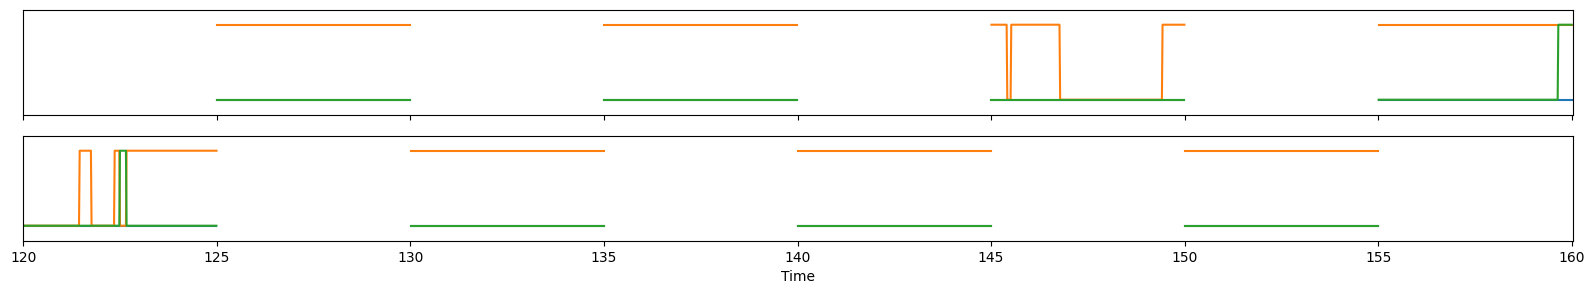

In [10]:
from pyannote.core import notebook, Segment
notebook.crop = Segment(120,160)

local_out_pretrained

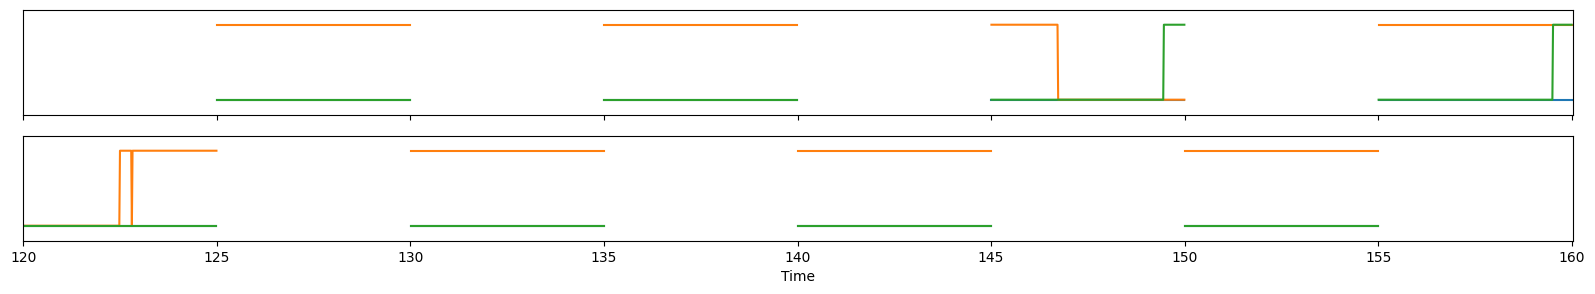

In [11]:
local_out_adapted

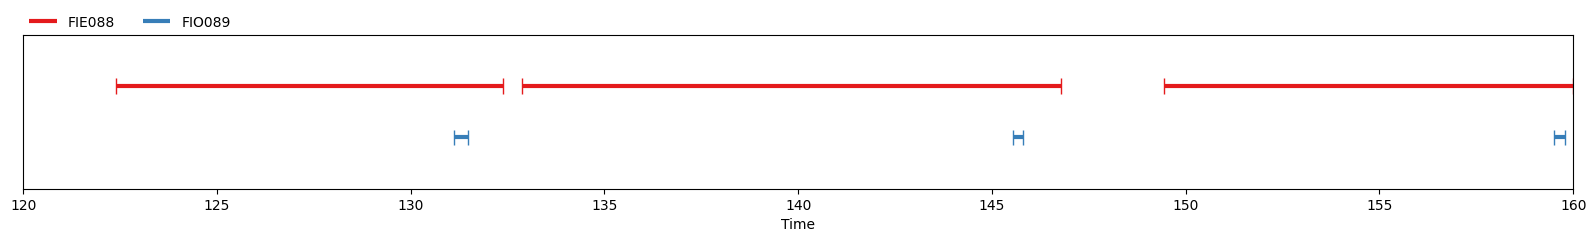

In [12]:
file1["annotation"]

## Adapted pipeline output
Now apply the full speaker diarization pipeline using the pretrained/adapted models to compare the outputs.
We can then observe the difference between pretrained/adapted/reference.

In [13]:
import pandas as pd
from pyannote.audio.pipelines import SpeakerDiarization as SpeakerDiarizationPipeline
from pyannote.metrics.diarization import DiarizationErrorRate

STEP = 5.0
PIPELINE_PARAMS = {
    "clustering": {
        "method": "centroid",
        "min_cluster_size": 15,
        "threshold": 0.6285824248662424,
    },
    "segmentation": {
        "min_duration_off": 0.0,
    },
}

# Initialize pipelines
adapted_model = Model.from_pretrained(checkpoint.best_model_path)
pipeline_adapted = SpeakerDiarizationPipeline(
    adapted_model,
    embedding="speechbrain/spkrec-ecapa-voxceleb",
    clustering="AgglomerativeClustering"
).to(device)
pipeline_adapted.instantiate(PIPELINE_PARAMS)

pipeline_pretrained = SpeakerDiarizationPipeline(
    PRETRAINED_PATH,
    embedding="speechbrain/spkrec-ecapa-voxceleb",
    clustering="AgglomerativeClustering"
).to(device)
pipeline_pretrained.instantiate(PIPELINE_PARAMS)

# Process all test files
test_files = list(protocol.test())
results = []

print(f"Processing {len(test_files)} test files...")
for idx, file in enumerate(test_files):
    print(f"Processing file {idx+1}/{len(test_files)}: {file['uri']}")

    # Run diarization on both pipelines
    out_pretrained = pipeline_pretrained(file)
    out_adapted = pipeline_adapted(file)

    # Calculate metrics for pretrained
    dermetric_pt = DiarizationErrorRate()
    _ = dermetric_pt(file["annotation"], out_pretrained, uem=file["annotated"])

    # Calculate metrics for adapted
    dermetric_ad = DiarizationErrorRate()
    _ = dermetric_ad(file["annotation"], out_adapted, uem=file["annotated"])

    # Store results
    results.append({
        'file_uri': file['uri'],
        'pretrained_fa': dermetric_pt["false alarm"] / dermetric_pt["total"],
        'pretrained_miss': dermetric_pt["missed detection"] / dermetric_pt["total"],
        'pretrained_conf': dermetric_pt["confusion"] / dermetric_pt["total"],
        'pretrained_der': abs(dermetric_pt),
        'adapted_fa': dermetric_ad["false alarm"] / dermetric_ad["total"],
        'adapted_miss': dermetric_ad["missed detection"] / dermetric_ad["total"],
        'adapted_conf': dermetric_ad["confusion"] / dermetric_ad["total"],
        'adapted_der': abs(dermetric_ad),
    })

# Create DataFrame and save to CSV
df = pd.DataFrame(results)

# Add percentage columns for easier reading
for col in ['fa', 'miss', 'conf', 'der']:
    df[f'pretrained_{col}_pct'] = df[f'pretrained_{col}'] * 100
    df[f'adapted_{col}_pct'] = df[f'adapted_{col}'] * 100

# Save to CSV
df.to_csv('diarization_results.csv', index=False)
print(f"\nResults saved to diarization_results.csv")

# Print summary statistics
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)
print(f"\n{'Metric':15} | {'Pretrained Mean':>15} | {'Adapted Mean':>15} | {'Improvement':>12}")
print("-"*80)
for metric in ['fa', 'miss', 'conf', 'der']:
    pt_mean = df[f'pretrained_{metric}'].mean() * 100
    ad_mean = df[f'adapted_{metric}'].mean() * 100
    improvement = pt_mean - ad_mean
    print(f"{metric.upper():15} | {pt_mean:14.2f}% | {ad_mean:14.2f}% | {improvement:+11.2f}%")

# Print detailed results table
print("\n" + "="*80)
print("DETAILED RESULTS BY FILE")
print("="*80)
print(f"{'File URI':30} | {'Model':10} | {'FA%':>6} | {'MISS%':>6} | {'CONF%':>6} | {'DER%':>6}")
print("-"*80)
for _, row in df.iterrows():
    print(f"{row['file_uri'][:30]:30} | {'Pretrained':10} | {row['pretrained_fa_pct']:6.2f} | {row['pretrained_miss_pct']:6.2f} | {row['pretrained_conf_pct']:6.2f} | {row['pretrained_der_pct']:6.2f}")
    print(f"{' ':30} | {'Adapted':10} | {row['adapted_fa_pct']:6.2f} | {row['adapted_miss_pct']:6.2f} | {row['adapted_conf_pct']:6.2f} | {row['adapted_der_pct']:6.2f}")
    print("-"*80)

/usr/local/lib/python3.12/dist-packages/pyannote/audio/core/io.py:212: UserWarning: torchaudio._backend.list_audio_backends has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be removed from the 2.9 release. 
  torchaudio.list_audio_backends()
INFO:speechbrain.utils.fetching:Fetch hyperparams.yaml: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will 

hyperparams.yaml: 0.00B [00:00, ?B/s]

DEBUG:speechbrain.utils.fetching:Fetch: Local file found, creating symlink '/root/.cache/huggingface/hub/models--speechbrain--spkrec-ecapa-voxceleb/snapshots/0f99f2d0ebe89ac095bcc5903c4dd8f72b367286/hyperparams.yaml' -> '/root/.cache/torch/pyannote/speechbrain/hyperparams.yaml'
INFO:speechbrain.utils.fetching:Fetch custom.py: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached
/usr/local/lib/python3.12/dist-packages/speechbrain/utils/torch_audio_backend.py:57: UserWarning: torchaudio._backend.list_audio_backends has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be removed from the 2.9 release. 
  available_backends = torchaudio.list_audio_backends()
DEBUG:speechbrain.utils.checkpoints:

embedding_model.ckpt:   0%|          | 0.00/83.3M [00:00<?, ?B/s]

DEBUG:speechbrain.utils.fetching:Fetch: Local file found, creating symlink '/root/.cache/huggingface/hub/models--speechbrain--spkrec-ecapa-voxceleb/snapshots/0f99f2d0ebe89ac095bcc5903c4dd8f72b367286/embedding_model.ckpt' -> '/root/.cache/torch/pyannote/speechbrain/embedding_model.ckpt'
DEBUG:speechbrain.utils.parameter_transfer:Set local path in self.paths["embedding_model"] = /root/.cache/torch/pyannote/speechbrain/embedding_model.ckpt
INFO:speechbrain.utils.fetching:Fetch mean_var_norm_emb.ckpt: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached


...

Model was trained with pyannote.audio 2.1.1, yours is 3.4.0. Bad things might happen unless you revert pyannote.audio to 2.x.
Model was trained with torch 1.13.0, yours is 2.8.0+cu126. Bad things might happen unless you revert torch to 1.x.


DEBUG:speechbrain.utils.parameter_transfer:Collecting files (or symlinks) for pretraining in /root/.cache/torch/pyannote/speechbrain.
INFO:speechbrain.utils.fetching:Fetch embedding_model.ckpt: Using symlink found at '/root/.cache/torch/pyannote/speechbrain/embedding_model.ckpt'
DEBUG:speechbrain.utils.parameter_transfer:Set local path in self.paths["embedding_model"] = /root/.cache/torch/pyannote/speechbrain/embedding_model.ckpt
INFO:speechbrain.utils.fetching:Fetch mean_var_norm_emb.ckpt: Using symlink found at '/root/.cache/torch/pyannote/speechbrain/mean_var_norm_emb.ckpt'
DEBUG:speechbrain.utils.parameter_transfer:Set local path in self.paths["mean_var_norm_emb"] = /root/.cache/torch/pyannote/speechbrain/mean_var_norm_emb.ckpt
INFO:speechbrain.utils.fetching:Fetch classifier.ckpt: Using symlink found at '/root/.cache/torch/pyannote/speechbrain/classifier.ckpt'
DEBUG:speechbrain.utils.parameter_transfer:Set local path in self.paths["classifier"] = /root/.cache/torch/pyannote/speech

Processing 16 test files...
Processing file 1/16: IS1009a


/usr/local/lib/python3.12/dist-packages/pyannote/audio/core/io.py:85: UserWarning: torchaudio._backend.utils.info has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be removed from the 2.9 release. 
  info = torchaudio.info(file["audio"], backend=backend)
/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/soundfile_backend.py:120: UserWarning: torchaudio._backend.common.AudioMetaData has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will

Processing file 2/16: IS1009b
Processing file 3/16: IS1009c
Processing file 4/16: IS1009d
Processing file 5/16: ES2004a
Processing file 6/16: ES2004b
Processing file 7/16: ES2004c
Processing file 8/16: ES2004d
Processing file 9/16: TS3003a
Processing file 10/16: TS3003b
Processing file 11/16: TS3003c
Processing file 12/16: TS3003d
Processing file 13/16: EN2002a
Processing file 14/16: EN2002b
Processing file 15/16: EN2002c
Processing file 16/16: EN2002d

Results saved to diarization_results.csv

SUMMARY STATISTICS

Metric          | Pretrained Mean |    Adapted Mean |  Improvement
--------------------------------------------------------------------------------
FA              |           5.05% |           4.17% |       +0.88%
MISS            |           9.50% |          13.33% |       -3.82%
CONF            |          14.97% |          12.03% |       +2.94%
DER             |          29.52% |          29.53% |       -0.01%

DETAILED RESULTS BY FILE
File URI                       | Model

In [14]:
from pyannote.audio.pipelines import SpeakerDiarization as SpeakerDiarizationPipeline

STEP=5.0

# hyperparameters used for AMI
PIPELINE_PARAMS = {
    "clustering": {
        "method": "centroid",
        "min_cluster_size": 15,
        "threshold": 0.6285824248662424,
    },
    "segmentation": {
        "min_duration_off": 0.0,
    },
}

adapted_model = Model.from_pretrained(checkpoint.best_model_path)
pipeline_adapted = SpeakerDiarizationPipeline(adapted_model, embedding="speechbrain/spkrec-ecapa-voxceleb", clustering="AgglomerativeClustering").to(device)
pipeline_adapted.instantiate(PIPELINE_PARAMS)
out_adapted = pipeline_adapted(next(protocol.test()))

pipeline_pretrained = SpeakerDiarizationPipeline(PRETRAINED_PATH, embedding="speechbrain/spkrec-ecapa-voxceleb", clustering="AgglomerativeClustering").to(device)
pipeline_pretrained.instantiate(PIPELINE_PARAMS)
out_pretrained = pipeline_pretrained(next(protocol.test()))

/usr/local/lib/python3.12/dist-packages/pyannote/audio/core/io.py:212: UserWarning: torchaudio._backend.list_audio_backends has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be removed from the 2.9 release. 
  torchaudio.list_audio_backends()
INFO:speechbrain.utils.fetching:Fetch hyperparams.yaml: Using symlink found at '/root/.cache/torch/pyannote/speechbrain/hyperparams.yaml'
INFO:speechbrain.utils.fetching:Fetch custom.py: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached
DEBUG:speechbrain.utils.parameter_transfer:Collecting files (or symlinks) for pretraining in /root/.cache/torch/pyannote/speechbrain.
INFO:speechbrain.utils.fetching:Fetch embedding_model.ckpt: Using symlink foun

Model was trained with pyannote.audio 2.1.1, yours is 3.4.0. Bad things might happen unless you revert pyannote.audio to 2.x.
Model was trained with torch 1.13.0, yours is 2.8.0+cu126. Bad things might happen unless you revert torch to 1.x.


DEBUG:speechbrain.utils.parameter_transfer:Collecting files (or symlinks) for pretraining in /root/.cache/torch/pyannote/speechbrain.
INFO:speechbrain.utils.fetching:Fetch embedding_model.ckpt: Using symlink found at '/root/.cache/torch/pyannote/speechbrain/embedding_model.ckpt'
DEBUG:speechbrain.utils.parameter_transfer:Set local path in self.paths["embedding_model"] = /root/.cache/torch/pyannote/speechbrain/embedding_model.ckpt
INFO:speechbrain.utils.fetching:Fetch mean_var_norm_emb.ckpt: Using symlink found at '/root/.cache/torch/pyannote/speechbrain/mean_var_norm_emb.ckpt'
DEBUG:speechbrain.utils.parameter_transfer:Set local path in self.paths["mean_var_norm_emb"] = /root/.cache/torch/pyannote/speechbrain/mean_var_norm_emb.ckpt
INFO:speechbrain.utils.fetching:Fetch classifier.ckpt: Using symlink found at '/root/.cache/torch/pyannote/speechbrain/classifier.ckpt'
DEBUG:speechbrain.utils.parameter_transfer:Set local path in self.paths["classifier"] = /root/.cache/torch/pyannote/speech

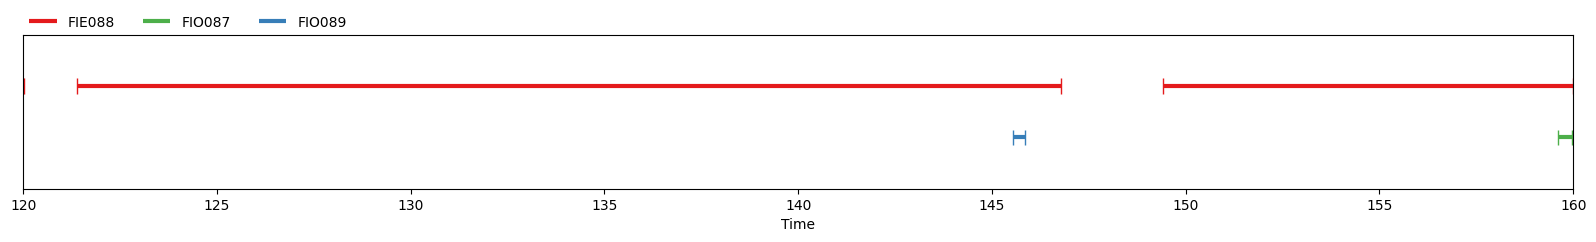

In [15]:
notebook.crop = Segment(120,160)

out_pretrained

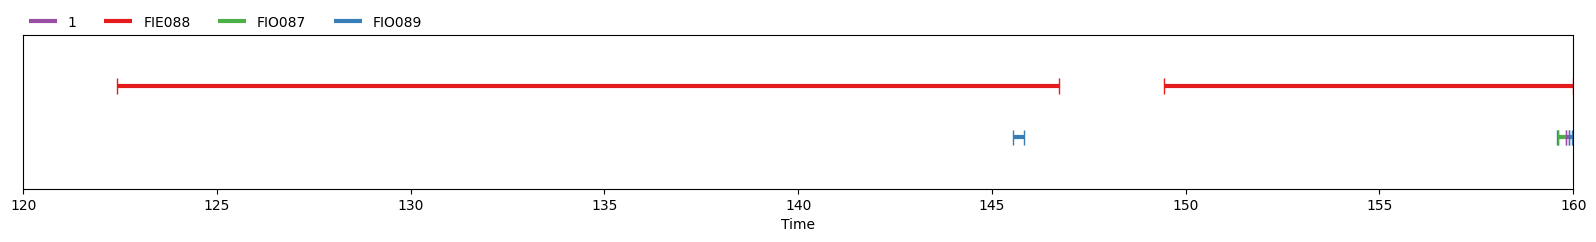

In [16]:
out_adapted

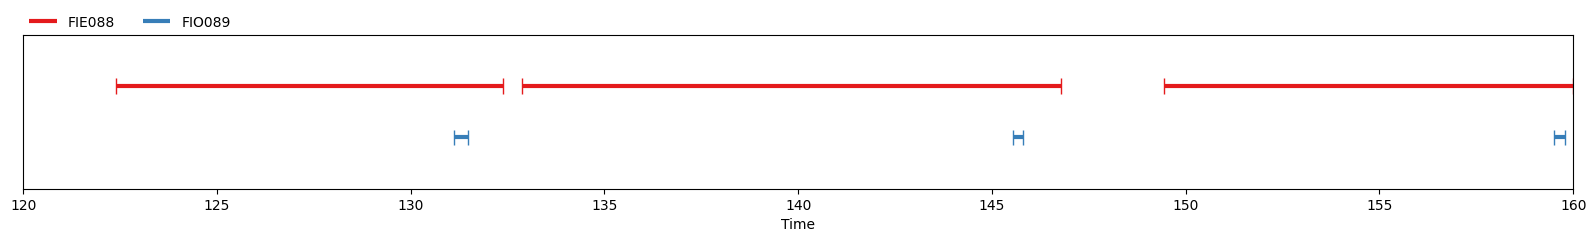

In [17]:
file1["annotation"]

## Evaluating the Diarization Error Rate (DER)

In [18]:
from pyannote.metrics.diarization import DiarizationErrorRate

def get_der(predictions, files):
  dermetric = DiarizationErrorRate()

  for file, pred in zip(files, predictions):
      # update der, computed between ground truth annotation and predicted
      # speech, on the file's uem.
      _ = dermetric(file["annotation"], pred, uem=file["annotated"])

  false_alarm = dermetric["false alarm"] / dermetric["total"]
  missed = dermetric["missed detection"] / dermetric["total"]
  confusion = dermetric["confusion"] / dermetric["total"]
  der = abs(dermetric)

  return false_alarm, missed, confusion, der


res_pt = {}
res_pt["fa"], res_pt["miss"], res_pt["conf"], res_pt["der"] = get_der([out_pretrained], [file1])

res_ad = {}
res_ad["fa"], res_ad["miss"], res_ad["conf"], res_ad["der"] = get_der([out_adapted], [file1])

print(f"On the first file of AMI mini ({file1['uri']}):")
print(f"{'Title':10} | {'FA%':>6} | {'MISS%':>6} | {'CONF%':>6} | {'DER%':>6}")
print(f"{'Pretrained':10} | {res_pt['fa']*100:6.2f} | {res_pt['miss']*100:6.2f} | {res_pt['conf']*100:6.2f} | {res_pt['der']*100:6.2f}")
print(f"{'Adapted':10} | {res_ad['fa']*100:6.2f} | {res_ad['miss']*100:6.2f} | {res_ad['conf']*100:6.2f} | {res_ad['der']*100:6.2f}")

On the first file of AMI mini (IS1009a):
Title      |    FA% |  MISS% |  CONF% |   DER%
Pretrained |   8.14 |   7.51 |  15.50 |  31.14
Adapted    |   7.59 |   8.29 |  11.85 |  27.72
